In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/mlokken/oriented_stacking/oriented_superclustering/")
import catalog

In [2]:
pkdata_python = catalog.Catalog(pathInCatalog="/mnt/scratch-lustre/mlokken/stacking/flamingo/dr1_lrg_allpython/lrg11p2_0pt90_0pt95_10pt0Mpc_asym_xy.csv")

- read input catalog from /mnt/scratch-lustre/mlokken/stacking/flamingo/dr1_lrg_allpython/lrg11p2_0pt90_0pt95_10pt0Mpc_asym_xy.csv


In [3]:
len(pkdata_python.alpha)

728489

In [4]:
pkdata_fortran = catalog.Catalog(pathInCatalog="/mnt/raid-cita/mlokken/data/flamingo/stacking_points/lrg11p2_lrg11p2_o10_100pct_0.9_0.95.csv")

- read input catalog from /mnt/raid-cita/mlokken/data/flamingo/stacking_points/lrg11p2_lrg11p2_o10_100pct_0.9_0.95.csv


In [5]:
len(pkdata_fortran.alpha)

728489

In [6]:
# make pandas df
import pandas as pd
df_python = pd.DataFrame({
    "RA": pkdata_python.RA,
    "DEC": pkdata_python.DEC,
    "alpha": pkdata_python.alpha,
    "Z": pkdata_python.Z
})

In [7]:
df_fortran = pd.DataFrame({
    "RA": pkdata_fortran.RA,
    "DEC": pkdata_fortran.DEC,
    "alpha": pkdata_fortran.alpha,
    "Z": pkdata_fortran.Z
})

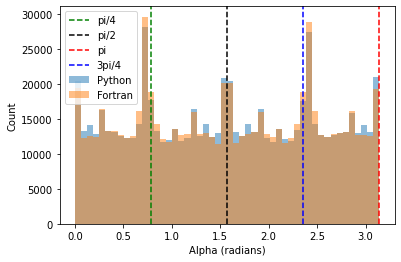

In [13]:
# histogram the original angles
# plt.hist(df_python.alpha, bins=50, alpha=0.5, label='Python')
# plt.hist(df_fortran.alpha, bins=50, alpha=0.5, label='Fortran')
plt.axvline(np.pi/4, color='g', linestyle='--', label='pi/4')
plt.axvline(np.pi/2, color='k', linestyle='--', label='pi/2')
plt.xlabel('Alpha (radians)')
plt.ylabel('Count')
plt.axvline(np.pi, color='r', linestyle='--', label='pi')
plt.axvline(3*np.pi/4, color='b', linestyle='--', label='3pi/4')

# plt.axvline(-np.pi, color='r', linestyle='--', label='-pi')
# plt.axvline(-np.pi/2, color='k', linestyle='--', label='-pi/2 degrees')
# plt.axvline(3*np.pi/2, color='k', linestyle='--', label='3pi/2')
plt.hist(df_python.alpha%np.pi, bins=50, alpha=0.5, label='Python')
plt.hist(df_fortran.alpha%np.pi, bins=50, alpha=0.5, label='Fortran')

plt.legend()

In [14]:
# sort boht by reshift
df_python_sorted = df_python.sort_values(by="Z").reset_index(drop=True)
df_fortran_sorted = df_fortran.sort_values(by="Z").reset_index(drop=True)
print(df_python_sorted.head())
print(df_fortran_sorted.head())

           RA        DEC     alpha         Z
0  284.331120 -18.114580  1.639528  0.907855
1  283.651150  -1.058584  2.175551  0.907855
2   64.437930 -15.457368  1.205355  0.907855
3   58.329006 -14.693891 -2.405901  0.907855
4  243.134340   0.195812 -2.886846  0.907855
           RA        DEC     alpha         Z
0  -75.673841 -18.092190  1.616600  0.907855
1  -76.333009  -1.044509  2.221372  0.907855
2   64.423826 -15.442787  4.298656  0.907855
3   58.315431 -14.708788  3.887189  0.907855
4 -116.894525   0.186509  0.360271  0.907855


In [15]:
# df_fortran RAs are -180 to 180, while df_python ones are 0 to 360. Convert df_fortran to 0 to 360 system.
df_fortran_sorted["RA"] = df_fortran_sorted["RA"] % 360

In [16]:
print(df_python_sorted.head())
print(df_fortran_sorted.head())

           RA        DEC     alpha         Z
0  284.331120 -18.114580  1.639528  0.907855
1  283.651150  -1.058584  2.175551  0.907855
2   64.437930 -15.457368  1.205355  0.907855
3   58.329006 -14.693891 -2.405901  0.907855
4  243.134340   0.195812 -2.886846  0.907855
           RA        DEC     alpha         Z
0  284.326159 -18.092190  1.616600  0.907855
1  283.666991  -1.044509  2.221372  0.907855
2   64.423826 -15.442787  4.298656  0.907855
3   58.315431 -14.708788  3.887189  0.907855
4  243.105475   0.186509  0.360271  0.907855


In [17]:
# alphas are also defined differently sometimes. They are headless vectors so we only care about the rotation from 0 to 180.
df_python_sorted["alpha"] = df_python_sorted["alpha"] % np.pi
df_fortran_sorted["alpha"] = df_fortran_sorted["alpha"] % np.pi
print(df_python_sorted.head())
print(df_fortran_sorted.head())

           RA        DEC     alpha         Z
0  284.331120 -18.114580  1.639528  0.907855
1  283.651150  -1.058584  2.175551  0.907855
2   64.437930 -15.457368  1.205355  0.907855
3   58.329006 -14.693891  0.735692  0.907855
4  243.134340   0.195812  0.254747  0.907855
           RA        DEC     alpha         Z
0  284.326159 -18.092190  1.616600  0.907855
1  283.666991  -1.044509  2.221372  0.907855
2   64.423826 -15.442787  1.157063  0.907855
3   58.315431 -14.708788  0.745597  0.907855
4  243.105475   0.186509  0.360271  0.907855


In [37]:
alpha_diffs = []

counter = 0
for i in range(10000):
    z_python = df_python_sorted.loc[i, "Z"]
    z_fortran = df_python_sorted.loc[i, "Z"]
    if np.isclose(z_python, z_fortran, atol=.05) and np.isclose(df_python_sorted.loc[i, "RA"], df_fortran_sorted.loc[i, "RA"], atol=.1) and np.isclose(df_python_sorted.loc[i, "DEC"], df_fortran_sorted.loc[i, "DEC"], atol=.1):
        print(f"Match found at index {i} in Python and index {i} in Fortran: {df_python_sorted.loc[i]} and {df_fortran_sorted.loc[i]}")
        # # plot the alphas as headless vectors
        # plt.quiver(0, 0, np.cos(df_python_sorted.loc[i, "alpha"]), np.sin(df_python_sorted.loc[i, "alpha"]), angles='xy', scale_units='xy', scale=1, color='r', label='Python')
        # # add the opposite arrow
        # plt.quiver(0, 0, -np.cos(df_python_sorted.loc[i, "alpha"]), -np.sin(df_python_sorted.loc[i, "alpha"]), angles='xy', scale_units='xy', scale=1, color='r')
        # plt.quiver(0, 0, np.cos(df_fortran_sorted.loc[j, "alpha"]), np.sin(df_fortran_sorted.loc[j, "alpha"]), angles='xy', scale_units='xy', scale=1, color='b', label='Fortran')
        # plt.quiver(0, 0, -np.cos(df_fortran_sorted.loc[j, "alpha"]), -np.sin(df_fortran_sorted.loc[j, "alpha"]), angles='xy', scale_units='xy', scale=1, color='b')
        # plt.show()
        # plt.clf()
        
        # check alpha differences considering only headless vectors
        alpha_diffs.append(df_python_sorted.loc[i, "alpha"] - df_fortran_sorted.loc[i, "alpha"])
        counter += 1
        if counter%10 == 0:
            print(f"Found {counter} matches so far.")


Match found at index 0 in Python and index 0 in Fortran: RA       284.331120
DEC      -18.114580
alpha      1.639528
Z          0.907855
Name: 0, dtype: float64 and RA       284.326159
DEC      -18.092190
alpha      1.616600
Z          0.907855
Name: 0, dtype: float64
Match found at index 1 in Python and index 1 in Fortran: RA       283.651150
DEC       -1.058584
alpha      2.175551
Z          0.907855
Name: 1, dtype: float64 and RA       283.666991
DEC       -1.044509
alpha      2.221372
Z          0.907855
Name: 1, dtype: float64
Match found at index 2 in Python and index 2 in Fortran: RA       64.437930
DEC     -15.457368
alpha     1.205355
Z         0.907855
Name: 2, dtype: float64 and RA       64.423826
DEC     -15.442787
alpha     1.157063
Z         0.907855
Name: 2, dtype: float64
Match found at index 3 in Python and index 3 in Fortran: RA       58.329006
DEC     -14.693891
alpha     0.735692
Z         0.907855
Name: 3, dtype: float64 and RA       58.315431
DEC     -14.708788
al

Text(0.5, 0, 'Alpha difference Python - Fortran [deg]')

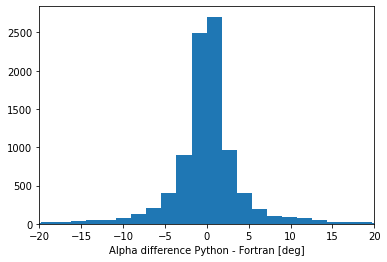

In [39]:
plt.hist(np.degrees(alpha_diffs), bins=200)
plt.xlim([-20, 20])
plt.xlabel("Alpha difference Python - Fortran [deg]")